In [ ]:
# Cell 1: Install pannu
!pip install opencv-python gradio numpy matplotlib scikit-image tensorflow


In [ ]:
# Cell 2: Libraries load pannu
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
import gradio as gr
from google.colab import files
from PIL import Image


In [ ]:
# Cell 3: Nee sketch upload pannu
print("Nee scribble upload pannu da:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Upload aachu: {filename}")

original = cv2.imread(filename)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)


Nee scribble upload pannu da:


Saving images.jpeg to images.jpeg
Upload aachu: images.jpeg


In [ ]:
# Cell 4: Image clean pannura pipeline
def preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    binary = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    kernel = np.ones((3,3), np.uint8)
    clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel)

    return clean

preprocessed = preprocess(original_rgb)


In [ ]:
# Cell 5: Scribble-a digital aakkuren
def enhance(preprocessed):
    # Edges detect pannuren
    edges = cv2.Canny(preprocessed, 50, 150)

    # Lines thin pannuren (skeleton)
    skeleton = morphology.skeletonize(preprocessed > 128)
    skeleton = (skeleton * 255).astype(np.uint8)

    # Smooth pannuren
    smooth = cv2.GaussianBlur(skeleton, (3,3), 0)

    # Thickness increase pannuren
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    final = cv2.morphologyEx(smooth, cv2.MORPH_DILATE, kernel)

    return final, edges, skeleton

digital, edges, skeleton = enhance(preprocessed)


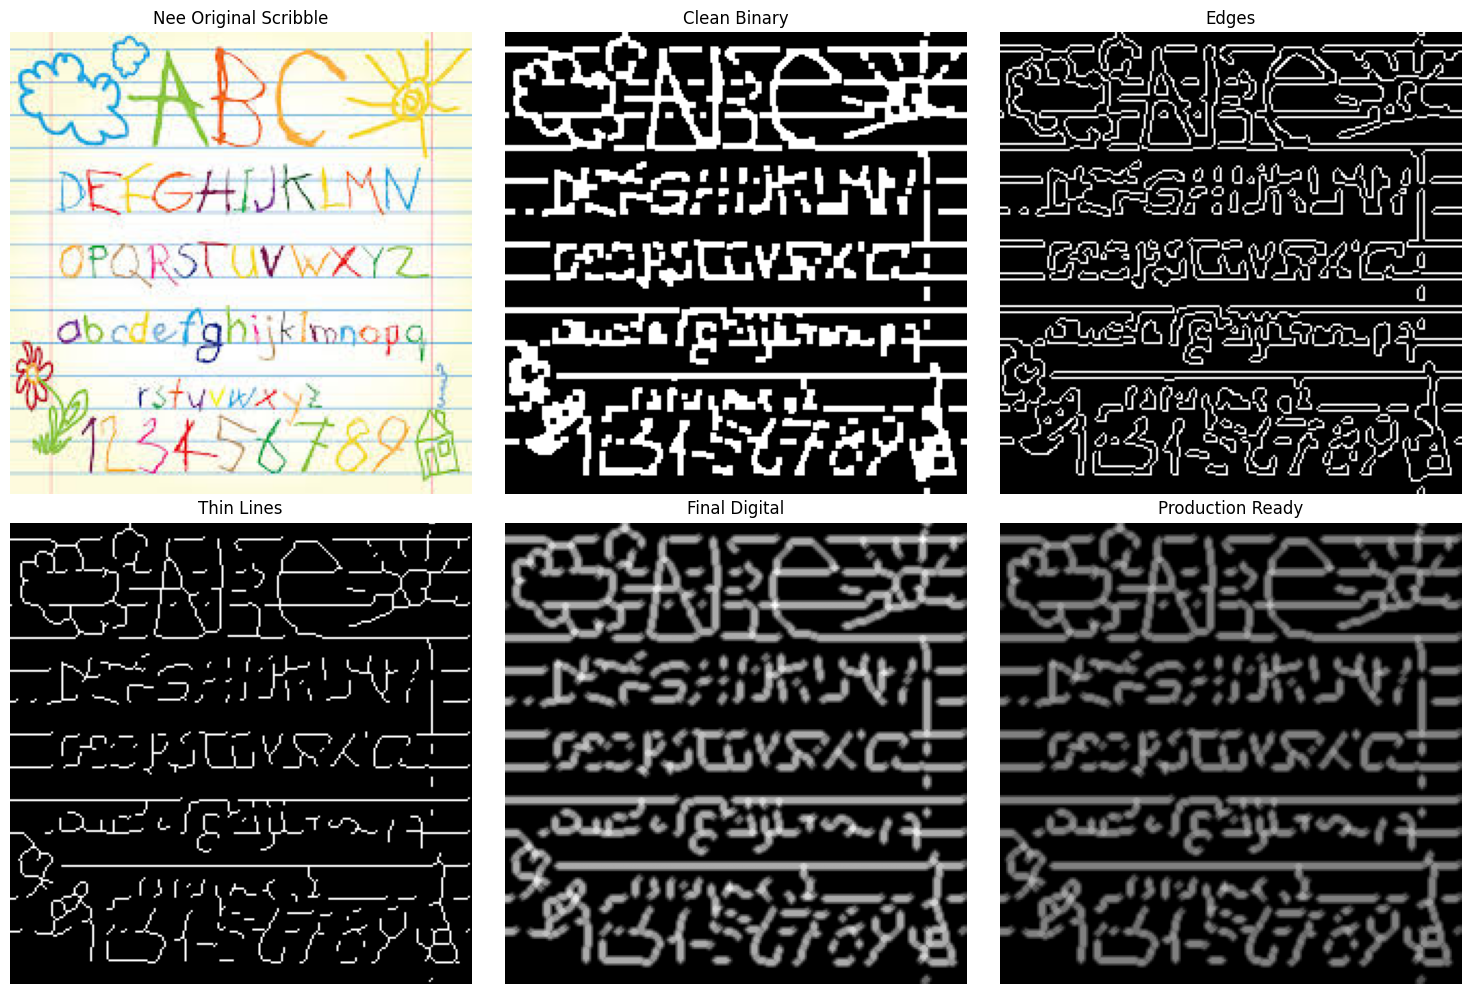

In [ ]:
# Cell 6: Before-After kaattu
fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes[0,0].imshow(original_rgb); axes[0,0].set_title('Nee Original Scribble'); axes[0,0].axis('off')
axes[0,1].imshow(preprocessed, cmap='gray'); axes[0,1].set_title('Clean Binary'); axes[0,1].axis('off')
axes[0,2].imshow(edges, cmap='gray'); axes[0,2].set_title('Edges'); axes[0,2].axis('off')

axes[1,0].imshow(skeleton, cmap='gray'); axes[1,0].set_title('Thin Lines'); axes[1,0].axis('off')
axes[1,1].imshow(digital, cmap='gray'); axes[1,1].set_title('Final Digital'); axes[1,1].axis('off')

final_color = cv2.cvtColor(digital, cv2.COLOR_GRAY2RGB)
axes[1,2].imshow(final_color); axes[1,2].set_title('Production Ready'); axes[1,2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 7: Click pannalaam, upload pannalaam
def full_pipeline(img):
    if img is None:
        return None, None, "Image upload pannu da!"

    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    preprocessed = preprocess(img_cv)
    final, _, _ = enhance(preprocessed)

    final_pil = Image.fromarray(final)
    return img, final_pil, "Success da! Clean aachu!"

app = gr.Interface(
    fn=full_pipeline,
    inputs=gr.Image(label="Nee Scribble Upload Pannu"),
    outputs=[gr.Image("Original"), gr.Image("Digital Output"), gr.Textbox()],
    title="🖌️ Scribble to Digital - Thanglish Edition",
    description="Hand sketch-a clean digital image-a convert pannuren!"
)

app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://90a33439bf67fed3a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Cell 8: Test pannu
print("Best results idhu work aagum:")
print("- Face drawings")
print("- Simple shapes")
print("- Flowcharts")
print("- UI wireframes")


Best results idhu work aagum:
- Face drawings
- Simple shapes
- Flowcharts
- UI wireframes


In [ ]:
# Cell 9: Final output save pannu
cv2.imwrite("clean_digital.png", digital)
files.download("clean_digital.png")
print("✅ Download aachu da!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download aachu da!
